# Week 3 Jupyter Notebook — Linear Regression 3


## Objective

This notebook applies Week 3 linear regression methods to the flight delay dataset. I tested forward selection, backward selection, principal component regression (PCR), and partial least squares regression (PLSR).

The goal was to see whether feature selection or dimensionality reduction could make the regression model simpler while still keeping similar predictive performance.


In [21]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

import warnings
warnings.filterwarnings("ignore")


## 1. Load the datasets

The main modeling data comes from the Kaggle `train.csv` and `test.csv` files. The BTS `Flight_Delay.csv` file is included as supporting context for delay causes in 2019.

This notebook uses a sample from the Kaggle data so the notebook runs more easily.

In [22]:
# Load data
# Data files are stored in the data folder.

SAMPLE_SIZE = 75000
TEST_SAMPLE_SIZE = 50000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)
test = pd.read_csv("data/test.csv", nrows=TEST_SAMPLE_SIZE)
flight_delay = pd.read_csv("data/Flight_delay.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Flight_Delay shape:", flight_delay.shape)

train.head()


Train shape: (75000, 30)
Test shape: (50000, 30)
Flight_Delay shape: (484551, 29)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA reminder

The target is `DEP_DEL15`, which means whether a flight had a departure delay of at least 15 minutes. This is a binary outcome, so these linear regression methods are still not the final ideal model. However, they are useful for understanding feature relationships and comparing modeling approaches across the weekly course topics.

The BTS data is used only as context here. It helps explain what types of delays were most important in the same 2019 period.

In [23]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\nMissing values, top 10:")
print(train.isna().sum().sort_values(ascending=False).head(10))


Target counts:
DEP_DEL15
0    60786
1    14214
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.05
1    18.95
Name: proportion, dtype: float64

Missing values, top 10:
MONTH                 0
DAY_OF_WEEK           0
DAY_HISTORICAL        0
DEP_AIRPORT_HIST      0
CARRIER_HISTORICAL    0
AWND                  0
TMAX                  0
SNWD                  0
SNOW                  0
PRCP                  0
dtype: int64


BTS total delay minutes by cause:
LateAircraftDelay    12915022
CarrierDelay          8440607
NASDelay              6589613
WeatherDelay          1527927
SecurityDelay           39749
dtype: int64


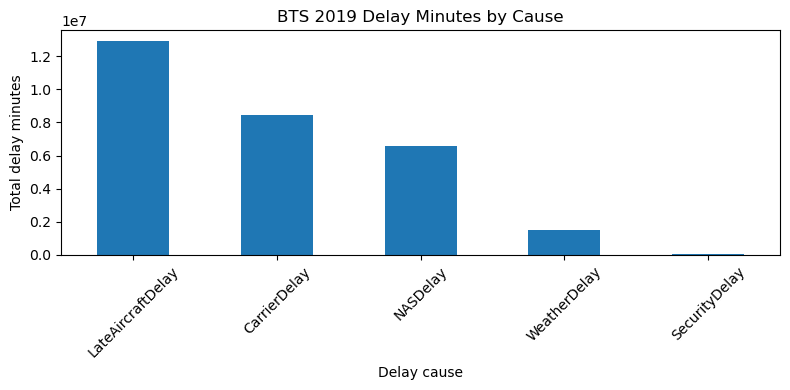

In [24]:
# BTS delay-cause context

bts_delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

available_bts_cols = [col for col in bts_delay_cols if col in flight_delay.columns]

if available_bts_cols:
    delay_totals = flight_delay[available_bts_cols].sum().sort_values(ascending=False)

    print("BTS total delay minutes by cause:")
    print(delay_totals)

    delay_totals.plot(kind="bar", figsize=(8, 4))
    plt.title("BTS 2019 Delay Minutes by Cause")
    plt.ylabel("Total delay minutes")
    plt.xlabel("Delay cause")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BTS delay-cause columns not found. Columns available:")
    print(flight_delay.columns.tolist())


## 3. Select modeling features

I am using the same general feature set as Weeks 1 and 2 so the results can be compared. These features include weather, airport activity, airline activity, route information, aircraft age, and historical delay patterns.

Keeping the feature set similar helps the weekly notebooks build one story instead of becoming separate unrelated analyses.

In [25]:
candidate_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

features = [col for col in candidate_features if col in train.columns]

model_data = train[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

print("Number of rows used:", X.shape[0])
print("Number of features used:", X.shape[1])
print("Features used:")
print(features)


Number of rows used: 75000
Number of features used: 25
Features used:
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']


## 4. Train/test split and baseline model

This baseline model gives a reference point. The selection and component methods should be compared against it. If a simpler model performs almost the same as the full model, that can still be useful because it is easier to explain.

In [26]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

def evaluate_model(name, model, X_train_data, X_valid_data, y_train_data, y_valid_data):
    model.fit(X_train_data, y_train_data)
    preds = model.predict(X_valid_data)

    rmse = mean_squared_error(y_valid_data, preds, squared=False)
    mae = mean_absolute_error(y_valid_data, preds)
    r2 = r2_score(y_valid_data, preds)

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_result = evaluate_model(
    "Full Linear Regression",
    baseline_model,
    X_train,
    X_valid,
    y_train,
    y_valid
)

pd.DataFrame([baseline_result])


,Model,RMSE,MAE,R2
0,Full Linear Regression,0.379383,0.287844,0.062858


## 5. Forward selection

Forward selection starts with no predictors. It tests which remaining feature improves the model the most, adds that feature, and repeats the process.

This is useful because it can create a smaller model and show which variables add predictive value first.

In [27]:
# Forward selection using validation RMSE
# To keep runtime reasonable, this selects up to 8 features.

max_features_to_select = 8

selected_features = []
remaining_features = features.copy()
forward_results = []

for step in range(max_features_to_select):
    step_results = []

    for feature in remaining_features:
        trial_features = selected_features + [feature]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ])

        model.fit(X_train[trial_features], y_train)
        preds = model.predict(X_valid[trial_features])
        rmse = mean_squared_error(y_valid, preds, squared=False)

        step_results.append({
            "Feature": feature,
            "RMSE": rmse
        })

    step_df = pd.DataFrame(step_results).sort_values("RMSE")
    best_feature = step_df.iloc[0]["Feature"]
    best_rmse = step_df.iloc[0]["RMSE"]

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    forward_results.append({
        "Step": step + 1,
        "Added Feature": best_feature,
        "Validation RMSE": best_rmse,
        "Selected Features": selected_features.copy()
    })

forward_results_df = pd.DataFrame(forward_results)
forward_results_df[["Step", "Added Feature", "Validation RMSE"]]


,Step,Added Feature,Validation RMSE
0,1,DEP_BLOCK_HIST,0.383761
1,2,PRCP,0.382157
2,3,CARRIER_HISTORICAL,0.381084
3,4,SNOW,0.380298
4,5,DEP_AIRPORT_HIST,0.380059
5,6,AWND,0.379875
6,7,MONTH,0.379809
7,8,SNWD,0.379740


In [28]:
# Evaluate final forward-selection model

forward_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

forward_result = evaluate_model(
    "Forward Selection Linear Regression",
    forward_model,
    X_train[selected_features],
    X_valid[selected_features],
    y_train,
    y_valid
)

print("Forward-selected features:")
print(selected_features)

pd.DataFrame([forward_result])


Forward-selected features:
['DEP_BLOCK_HIST', 'PRCP', 'CARRIER_HISTORICAL', 'SNOW', 'DEP_AIRPORT_HIST', 'AWND', 'MONTH', 'SNWD']


,Model,RMSE,MAE,R2
0,Forward Selection Linear Regression,0.37974,0.288435,0.061095


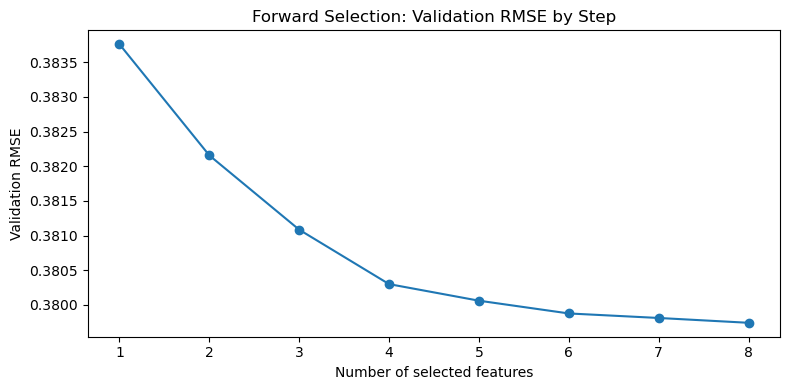

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(forward_results_df["Step"], forward_results_df["Validation RMSE"], marker="o")
plt.title("Forward Selection: Validation RMSE by Step")
plt.xlabel("Number of selected features")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()


## 6. Backward selection

Backward selection starts with all predictors and removes the least useful ones. Here, I remove features one at a time and keep the removal if it improves or barely changes validation RMSE.

This is useful because it checks whether the full feature set contains variables that are adding noise or redundancy.

In [30]:
# Backward selection using validation RMSE
# To keep runtime reasonable, this removes down to 8 features.

backward_features = features.copy()
backward_results = []

while len(backward_features) > 8:
    removal_results = []

    for feature in backward_features:
        trial_features = [f for f in backward_features if f != feature]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ])

        model.fit(X_train[trial_features], y_train)
        preds = model.predict(X_valid[trial_features])
        rmse = mean_squared_error(y_valid, preds, squared=False)

        removal_results.append({
            "Removed Feature": feature,
            "RMSE": rmse,
            "Remaining Feature Count": len(trial_features)
        })

    removal_df = pd.DataFrame(removal_results).sort_values("RMSE")
    feature_to_remove = removal_df.iloc[0]["Removed Feature"]
    best_rmse = removal_df.iloc[0]["RMSE"]

    backward_features.remove(feature_to_remove)

    backward_results.append({
        "Removed Feature": feature_to_remove,
        "Validation RMSE": best_rmse,
        "Remaining Feature Count": len(backward_features),
        "Remaining Features": backward_features.copy()
    })

backward_results_df = pd.DataFrame(backward_results)
backward_results_df[["Remaining Feature Count", "Removed Feature", "Validation RMSE"]].head(10)


,Remaining Feature Count,Removed Feature,Validation RMSE
0,24,DAY_HISTORICAL,0.379373
1,23,DAY_OF_WEEK,0.379371
2,22,AIRLINE_AIRPORT_FLIGHTS_MONTH,0.379377
3,21,SEGMENT_NUMBER,0.379388
4,20,FLT_ATTENDANTS_PER_PASS,0.379398
5,19,LONGITUDE,0.379415
6,18,AIRLINE_FLIGHTS_MONTH,0.379422
7,17,AVG_MONTHLY_PASS_AIRLINE,0.379405
8,16,PLANE_AGE,0.379428
9,15,LATITUDE,0.379460


In [31]:
# Evaluate final backward-selection model

backward_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

backward_result = evaluate_model(
    "Backward Selection Linear Regression",
    backward_model,
    X_train[backward_features],
    X_valid[backward_features],
    y_train,
    y_valid
)

print("Backward-selected features:")
print(backward_features)

pd.DataFrame([backward_result])


Backward-selected features:
['CONCURRENT_FLIGHTS', 'AIRPORT_FLIGHTS_MONTH', 'PRCP', 'SNOW', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DEP_BLOCK_HIST']


,Model,RMSE,MAE,R2
0,Backward Selection Linear Regression,0.379842,0.288565,0.06059


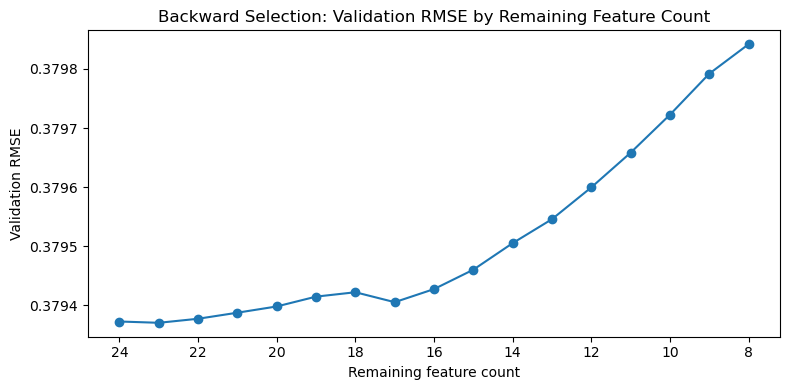

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(backward_results_df["Remaining Feature Count"], backward_results_df["Validation RMSE"], marker="o")
plt.title("Backward Selection: Validation RMSE by Remaining Feature Count")
plt.xlabel("Remaining feature count")
plt.ylabel("Validation RMSE")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()


## 7. Principal Component Regression (PCR)

PCR uses PCA to turn the original predictors into principal components. These components are uncorrelated, so PCR directly helps with the multicollinearity issue from Week 1.

The tradeoff is that principal components are harder to interpret than the original variables.

In [33]:
# PCR: test different numbers of components

component_range = list(range(2, min(len(features), 15) + 1))

pcr_results = []

for n_components in component_range:
    pcr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)),
        ("model", LinearRegression())
    ])

    pcr_model.fit(X_train, y_train)
    preds = pcr_model.predict(X_valid)

    pcr_results.append({
        "Model": "PCR",
        "Components": n_components,
        "RMSE": mean_squared_error(y_valid, preds, squared=False),
        "MAE": mean_absolute_error(y_valid, preds),
        "R2": r2_score(y_valid, preds)
    })

pcr_results_df = pd.DataFrame(pcr_results)
pcr_results_df.sort_values("RMSE").head(10)


,Model,Components,RMSE,MAE,R2
13,PCR,15,0.380098,0.288737,0.059322
11,PCR,13,0.380387,0.289135,0.057893
10,PCR,12,0.380388,0.289143,0.057885
12,PCR,14,0.380444,0.289133,0.057611
9,PCR,11,0.380486,0.289286,0.057399
8,PCR,10,0.380915,0.289966,0.055277
7,PCR,9,0.381593,0.290852,0.051909
6,PCR,8,0.381798,0.291135,0.050888
5,PCR,7,0.383218,0.293360,0.043815
4,PCR,6,0.383422,0.293546,0.042796


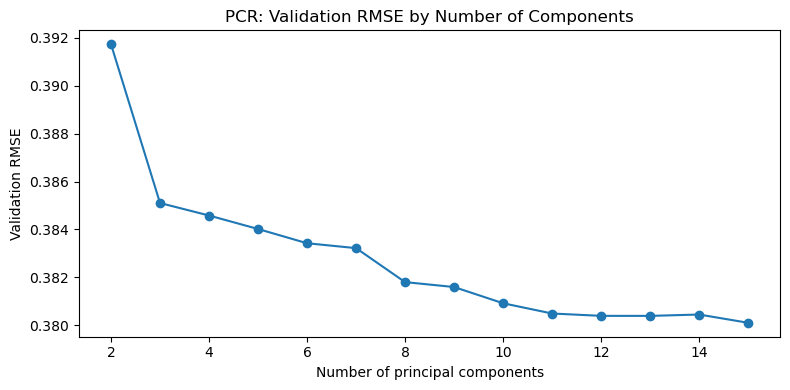

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(pcr_results_df["Components"], pcr_results_df["RMSE"], marker="o")
plt.title("PCR: Validation RMSE by Number of Components")
plt.xlabel("Number of principal components")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()


In [35]:
# Explained variance for PCA components

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=min(len(features), 15), random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

explained_variance = pd.DataFrame({
    "Component": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance.head(15)


,Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.137698,0.137698
1,2,0.103738,0.241436
2,3,0.090985,0.332421
3,4,0.074936,0.407356
4,5,0.067858,0.475214
5,6,0.055974,0.531188
6,7,0.051777,0.582965
7,8,0.042886,0.625850
8,9,0.040552,0.666403
9,10,0.040224,0.706627


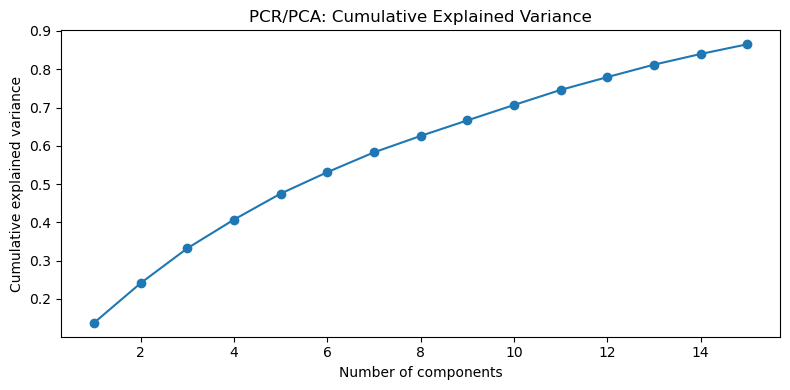

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(
    explained_variance["Component"],
    explained_variance["Cumulative Explained Variance"],
    marker="o"
)
plt.title("PCR/PCA: Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.show()


## 8. Partial Least Squares Regression (PLSR)

PLSR is similar to PCR because it creates components, but it uses the target variable while creating those components. That means PLSR is usually more prediction-focused than PCR.

This is useful for this project because some features may not explain the most overall variance in the dataset, but they may still be useful for predicting delay risk.

In [37]:
# PLSR: test different numbers of components

plsr_results = []

for n_components in component_range:
    plsr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=n_components))
    ])

    plsr_model.fit(X_train, y_train)
    preds = plsr_model.predict(X_valid).ravel()

    plsr_results.append({
        "Model": "PLSR",
        "Components": n_components,
        "RMSE": mean_squared_error(y_valid, preds, squared=False),
        "MAE": mean_absolute_error(y_valid, preds),
        "R2": r2_score(y_valid, preds)
    })

plsr_results_df = pd.DataFrame(plsr_results)
plsr_results_df.sort_values("RMSE").head(10)


,Model,Components,RMSE,MAE,R2
13,PLSR,15,0.379388,0.287848,0.062834
11,PLSR,13,0.379389,0.287850,0.062830
10,PLSR,12,0.379393,0.287852,0.062809
12,PLSR,14,0.379393,0.287852,0.062809
9,PLSR,11,0.379395,0.287860,0.062800
8,PLSR,10,0.379417,0.287866,0.062693
7,PLSR,9,0.379419,0.287861,0.062678
6,PLSR,8,0.379460,0.287884,0.062477
5,PLSR,7,0.379477,0.287897,0.062395
4,PLSR,6,0.379494,0.287930,0.062311


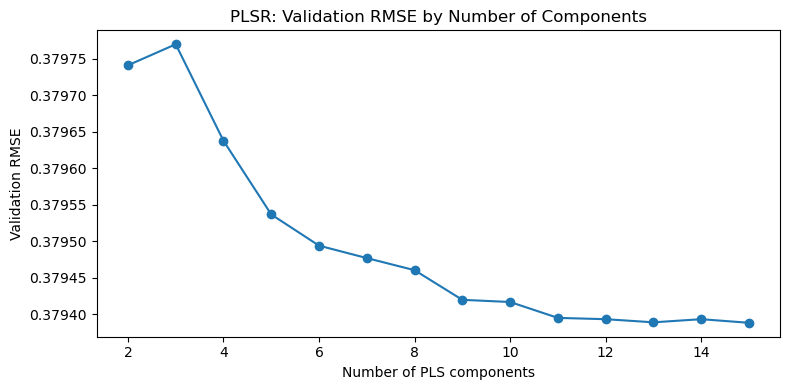

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(plsr_results_df["Components"], plsr_results_df["RMSE"], marker="o")
plt.title("PLSR: Validation RMSE by Number of Components")
plt.xlabel("Number of PLS components")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()


## 9. Compare Week 3 methods

This table compares the full linear regression baseline, forward selection, backward selection, the best PCR model, and the best PLSR model.

In [39]:
best_pcr = pcr_results_df.sort_values("RMSE").iloc[0].to_dict()
best_pcr_result = {
    "Model": f"PCR ({int(best_pcr['Components'])} components)",
    "RMSE": best_pcr["RMSE"],
    "MAE": best_pcr["MAE"],
    "R2": best_pcr["R2"]
}

best_plsr = plsr_results_df.sort_values("RMSE").iloc[0].to_dict()
best_plsr_result = {
    "Model": f"PLSR ({int(best_plsr['Components'])} components)",
    "RMSE": best_plsr["RMSE"],
    "MAE": best_plsr["MAE"],
    "R2": best_plsr["R2"]
}

comparison_df = pd.DataFrame([
    baseline_result,
    forward_result,
    backward_result,
    best_pcr_result,
    best_plsr_result
]).sort_values("RMSE")

comparison_df


,Model,RMSE,MAE,R2
0,Full Linear Regression,0.379383,0.287844,0.062858
4,PLSR (15 components),0.379388,0.287848,0.062834
1,Forward Selection Linear Regression,0.379740,0.288435,0.061095
2,Backward Selection Linear Regression,0.379842,0.288565,0.060590
3,PCR (15 components),0.380098,0.288737,0.059322


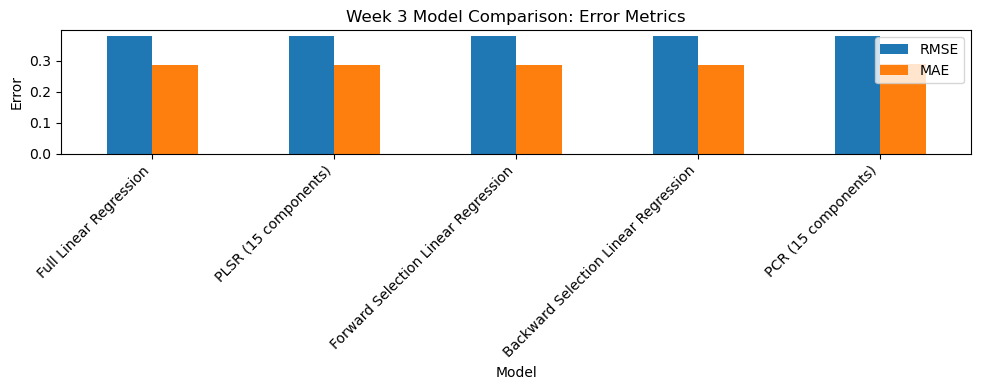

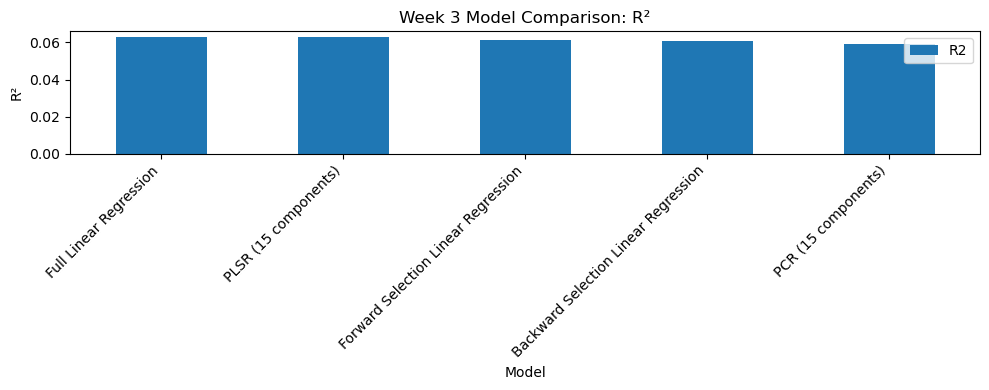

In [40]:
comparison_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(10, 4))
plt.title("Week 3 Model Comparison: Error Metrics")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

comparison_df.set_index("Model")[["R2"]].plot(kind="bar", figsize=(10, 4))
plt.title("Week 3 Model Comparison: R²")
plt.ylabel("R²")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Week 3 Conclusion

In this notebook, I tested forward selection, backward selection, PCR, and PLSR on the flight delay dataset. These methods were useful because they tested whether a simpler set of predictors or a smaller set of components could perform close to the full regression model.

Forward and backward selection helped identify which variables carried more predictive information. PCR and PLSR reduced the predictors into components, which helped deal with related variables and model complexity. The results showed that simplifying the model did not greatly improve performance, although PLSR stayed close to the full model.

Overall, Week 3 showed that feature selection and component methods can make the model easier to interpret, but they did not solve the low predictive strength of the linear regression approach for this delay target.
